<a href="https://colab.research.google.com/github/Fatma3598/elsewedy-demand-forecasting/blob/main/Notebooks/ElSewedy_Demand_Inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Machine Learning Inference**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
from datetime import datetime, timedelta
import warnings
import joblib
import time
import glob
warnings.filterwarnings('ignore')


# **Configuration**

In [ ]:
FORECAST_HORIZON = 6  # months ahead
TEST_SIZE = 0.2
RANDOM_STATE = 42

# **Loading Data**

In [ ]:
print("\n Loading elsewedy dataset...")
df = pd.read_csv('elsewedy_materials_dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])
print(f" Loaded {len(df):,} records")


 Loading elsewedy dataset...
 Loaded 612 records


# **Preparing Data**

In [ ]:

# ============================================================================
# FEATURE ENGINEERING
# ============================================================================

print("\n Feature Engineering...")

# Temporal features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['DayOfYear'] = df['Date'].dt.dayofyear

# Cyclical encoding for month (better for seasonality)
df['Month_Sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_Cos'] = np.cos(2 * np.pi * df['Month'] / 12)

# Lag features (previous months demand)
df = df.sort_values(['Item_Code', 'Date'])
for lag in [1, 2, 3, 6]:
    df[f'Demand_Lag_{lag}'] = df.groupby('Item_Code')['Historical_Demand_Quantity (TON)'].shift(lag)

# Rolling statistics (moving averages)
for window in [3, 6]:
    df[f'Demand_MA_{window}'] = df.groupby('Item_Code')['Historical_Demand_Quantity (TON)'].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )
    df[f'Demand_Std_{window}'] = df.groupby('Item_Code')['Historical_Demand_Quantity (TON)'].transform(
        lambda x: x.rolling(window=window, min_periods=1).std()
    )

# Demand growth rate
df['Demand_Growth'] = df.groupby('Item_Code')['Historical_Demand_Quantity (TON)'].pct_change()

# Stock ratios
df['Stock_To_Demand_Ratio'] = df['Current_Stock_Level (TON)'] / (df['Historical_Demand_Quantity (TON)'] + 0.01)
df['Safety_Stock_Coverage'] = df['Safety_Stock_Target (TON)'] / (df['Historical_Demand_Quantity (TON)'] + 0.01)

# Categorical encoding
le_material = LabelEncoder()
le_voltage = LabelEncoder()
le_supplier = LabelEncoder()

df['Material_Type_Encoded'] = le_material.fit_transform(df['Material_Type'])
df['Voltage_Level_Encoded'] = le_voltage.fit_transform(df['Voltage_Level'])
df['Supplier_Encoded'] = le_supplier.fit_transform(df['Supplier'])

# Drop rows with NaN from lag features (first few months)
df_model = df.dropna().copy()

print(f" Features created. Dataset size after cleaning: {len(df_model):,}")



 Feature Engineering...
 Features created. Dataset size after cleaning: 510


In [ ]:
# Target variable
target = 'Historical_Demand_Quantity (TON)'

# Feature selection
feature_cols = [
    # Temporal
    'Year', 'Month', 'Quarter', 'Month_Sin', 'Month_Cos',

    # Material characteristics
    'Material_Type_Encoded', 'Voltage_Level_Encoded',

    # Demand history
    'Demand_Lag_1', 'Demand_Lag_2', 'Demand_Lag_3', 'Demand_Lag_6',
    'Demand_MA_3', 'Demand_MA_6', 'Demand_Std_3', 'Demand_Std_6',
    'Demand_Growth',

    # Inventory
    'Current_Stock_Level (TON)', 'Safety_Stock_Target (TON)',
    'Stock_To_Demand_Ratio', 'Safety_Stock_Coverage',

    # Supply chain
    'Delivery_Lead_Time (Days)', 'Number_Of_Alternative_Suppliers',
    'Supplier_Performance_Score (1-10)', 'Risk_Score (1-10)',
    'Supplier_Encoded',

    # Market
    'Price_Per_Unit (USD)', 'Market_Trends (Index)',
]

# **Data Splitting**

In [ ]:
X = df_model[feature_cols].copy()
y = df_model[target].copy()

print(f"\n Features: {len(feature_cols)}")
print(f" Target: {target}")



 Features: 27
 Target: Historical_Demand_Quantity (TON)


In [ ]:
# Time-based split (keep temporal order)
split_date = df_model['Date'].quantile(0.8)
train_mask = df_model['Date'] < split_date
test_mask = df_model['Date'] >= split_date

X_train = X[train_mask]
X_test = X[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

In [ ]:
print(f"\n Training set: {len(X_train):,} samples ({X_train.index.min()} to {X_train.index.max()})")
print(f" Test set: {len(X_test):,} samples ({X_test.index.min()} to {X_test.index.max()})")


 Training set: 408 samples (102 to 509)
 Test set: 102 samples (510 to 611)


# **Scaling Data**

In [ ]:
print(f" Test set: {len(X_test):,} samples ({X_test.index.min()} to {X_test.index.max()})")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

 Test set: 102 samples (510 to 611)


# **Models Loading and Prediction**

In [ ]:
models = {}
predictions = {}

ml_files = glob.glob("*.joblib")
for model_file in ml_files:
  loaded_model = joblib.load(model_file)
  clean_name = model_file.removesuffix("_model.joblib")

  start_time = time.time()
  predictions[clean_name] = loaded_model.predict(X_test_scaled)
  end_time = time.time()

  predicting_time = end_time - start_time
  print(f'{clean_name} Predicting Time: {predicting_time:.4f} seconds')
  models[clean_name] = loaded_model

xgboost Predicting Time: 0.0189 seconds
gradient_boosting Predicting Time: 0.0036 seconds
random_forest Predicting Time: 0.0565 seconds


# **Evaluation**

In [ ]:
print("\n" + "="*70)
print("MODEL EVALUATION RESULTS")
print("="*70)

results = []

for name, y_pred in predictions.items():
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / (y_test + 0.01))) * 100

    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'MAPE (%)': mape
    })

    print(f"\n{name}:")
    print(f"   MAE:  {mae:.2f} TON")
    print(f"   RMSE: {rmse:.2f} TON")
    print(f"   R²:   {r2:.4f}")
    print(f"   MAPE: {mape:.2f}%")

results_df = pd.DataFrame(results)

# Select best model
best_model_name = results_df.loc[results_df['R²'].idxmax(), 'Model']
best_model = models[best_model_name]

print(f"\n Best Model: {best_model_name}")

# ============================================================================
# FEATURE IMPORTANCE
# ============================================================================

print("\n" + "="*70)
print("FEATURE IMPORTANCE (Top 15)")
print("="*70)

if best_model_name in ['random_forest', 'xgboost', 'gradient_boosting']:
    feature_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    print("\n" + feature_importance.head(15).to_string(index=False))


MODEL EVALUATION RESULTS

xgboost:
   MAE:  1.36 TON
   RMSE: 2.57 TON
   R²:   0.9777
   MAPE: 3.52%

gradient_boosting:
   MAE:  1.28 TON
   RMSE: 2.10 TON
   R²:   0.9851
   MAPE: 3.48%

random_forest:
   MAE:  1.58 TON
   RMSE: 2.94 TON
   R²:   0.9709
   MAPE: 4.19%

 Best Model: gradient_boosting

FEATURE IMPORTANCE (Top 15)

                  Feature  Importance
              Demand_MA_3    0.927232
              Demand_MA_6    0.022081
            Demand_Growth    0.020664
             Demand_Lag_1    0.006427
             Demand_Std_6    0.004705
             Demand_Std_3    0.002829
             Demand_Lag_3    0.002378
Current_Stock_Level (TON)    0.002367
    Safety_Stock_Coverage    0.001497
             Demand_Lag_2    0.001176
             Demand_Lag_6    0.001143
     Price_Per_Unit (USD)    0.000915
Safety_Stock_Target (TON)    0.000911
    Stock_To_Demand_Ratio    0.000851
        Risk_Score (1-10)    0.000715


In [ ]:
print("\n" + "="*70)
print(f"GENERATING {FORECAST_HORIZON}-MONTH FORECAST")
print("="*70)

# Get latest data for each material
latest_data = df_model.loc[df_model.groupby('Item_Code')['Date'].idxmax()].copy()

# Initialize forecast results
forecast_results = []

for idx, row in latest_data.iterrows():
    material_code = row['Item_Code']
    material_type = row['Material_Type']

    # Generate forecasts for next 6 months
    current_row = row.copy()

    for month_ahead in range(1, FORECAST_HORIZON + 1):
        # Update date
        forecast_date = current_row['Date'] + timedelta(days=30 * month_ahead)

        # Update temporal features
        current_row['Year'] = forecast_date.year
        current_row['Month'] = forecast_date.month
        current_row['Quarter'] = (forecast_date.month - 1) // 3 + 1
        current_row['Month_Sin'] = np.sin(2 * np.pi * forecast_date.month / 12)
        current_row['Month_Cos'] = np.cos(2 * np.pi * forecast_date.month / 12)

        # Prepare features
        X_forecast = current_row[feature_cols].values.reshape(1, -1)
        X_forecast_scaled = scaler.transform(X_forecast)

        # Predict
        forecast_demand = best_model.predict(X_forecast_scaled)[0]
        forecast_demand = max(0, forecast_demand)  # No negative demand

        # Calculate recommended safety stock based on risk
        lead_time = current_row['Delivery_Lead_Time (Days)']
        risk_score = current_row['Risk_Score (1-10)']
        risk_multiplier = 1 + (risk_score / 10) * 0.5
        safety_stock = (forecast_demand * (lead_time / 30)) * risk_multiplier

        # Store forecast
        forecast_results.append({
            'Item_Code': material_code,
            'Material_Type': material_type,
            'Forecast_Date': forecast_date,
            'Forecast_Month': forecast_date.strftime('%Y-%m'),
            'Predicted_Demand (TON)': round(forecast_demand, 2),
            'Recommended_Safety_Stock (TON)': round(safety_stock, 2),
            'Risk_Score': risk_score,
            'Supply_Risk_Flag': 'High' if risk_score >= 7 else 'Medium' if risk_score >= 4 else 'Low'
        })

        # Update lag features for next iteration
        current_row['Demand_Lag_6'] = current_row['Demand_Lag_3']
        current_row['Demand_Lag_3'] = current_row['Demand_Lag_2']
        current_row['Demand_Lag_2'] = current_row['Demand_Lag_1']
        current_row['Demand_Lag_1'] = forecast_demand

forecast_df = pd.DataFrame(forecast_results)

# Save forecast
forecast_df.to_csv('elsewedy_demand_forecast.csv', index=False)
print(f"\nForecast saved to: elsewedy_demand_forecast.csv")

# Display sample forecasts
print("\nSample Forecasts (XLPE Materials):")
print("-" * 70)
sample_forecast = forecast_df[forecast_df['Material_Type'] == 'XLPE'].head(12)
print(sample_forecast.to_string(index=False))



GENERATING 6-MONTH FORECAST

Forecast saved to: elsewedy_demand_forecast.csv

Sample Forecasts (XLPE Materials):
----------------------------------------------------------------------
    Item_Code Material_Type Forecast_Date Forecast_Month  Predicted_Demand (TON)  Recommended_Safety_Stock (TON)  Risk_Score Supply_Risk_Flag
XLPE-11KV-INS          XLPE    2024-12-31        2024-12                   75.84                          119.80         4.3           Medium
XLPE-11KV-INS          XLPE    2025-01-30        2025-01                   75.15                          118.71         4.3           Medium
XLPE-11KV-INS          XLPE    2025-03-01        2025-03                   75.44                          119.16         4.3           Medium
XLPE-11KV-INS          XLPE    2025-03-31        2025-03                   73.90                          116.73         4.3           Medium
XLPE-11KV-INS          XLPE    2025-04-30        2025-04                   74.34                         

# **Visualization**


Generating forecast visualizations...
Forecast visualizations saved to: elsewedy_forecast_results.png
Risk analysis saved to: elsewedy_forecast_risk_analysis.png

FORECAST SUMMARY REPORT

6-Month Forecast Period: 2024-12 to 2025-05
Total Forecasted Demand: 3,540.19 TON
Total Recommended Safety Stock: 5,347.85 TON
High-Risk Forecasts: 0 out of 102 (0.0%)

Top 3 Materials by Forecast Demand:
   1. XLPE: 1,119.62 TON
   2. Semiconductor: 600.00 TON
   3. PVC: 496.96 TON

FORECASTING COMPLETE!

 Output Files Generated:
   1. elsewedy_demand_forecast.csv - Detailed 6-month forecasts
   2. elsewedy_forecast_results.png - Model performance & forecasts
   3. elsewedy_forecast_risk_analysis.png - Risk-based analysis


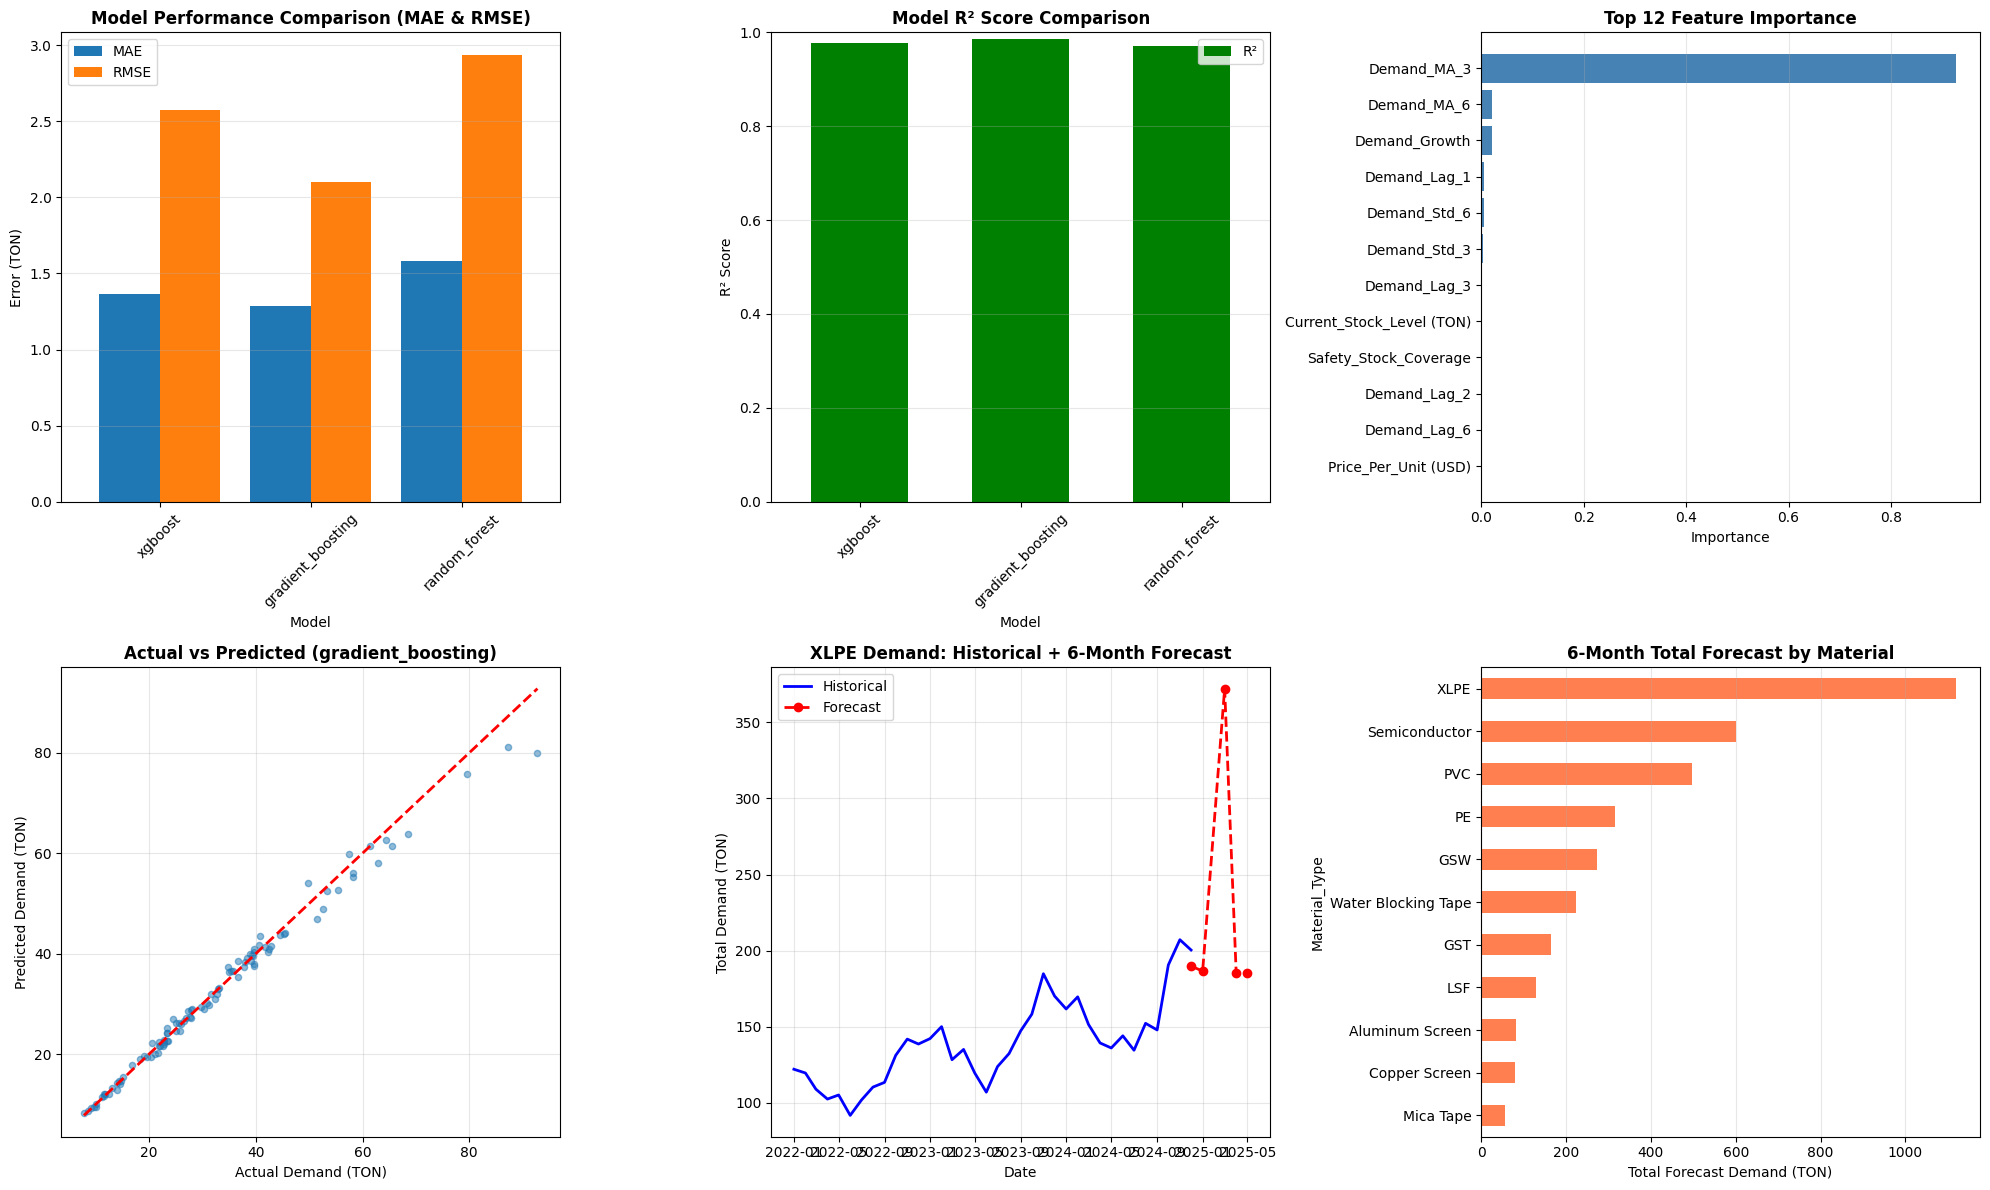

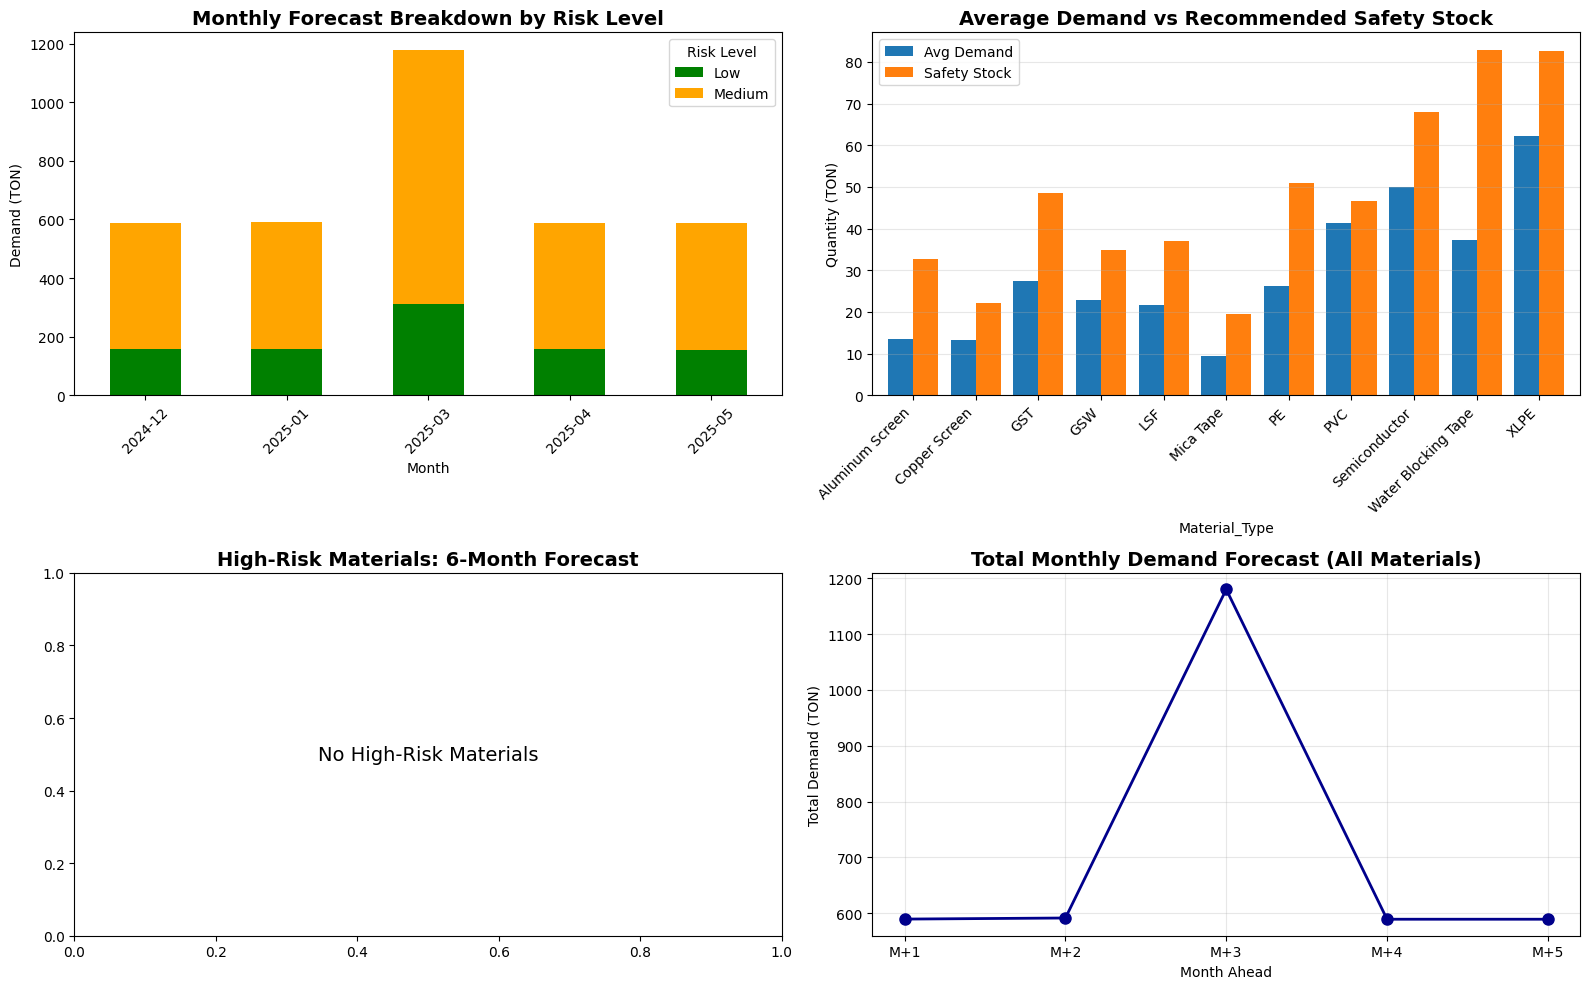

In [ ]:
print("\nGenerating forecast visualizations...")

fig = plt.figure(figsize=(20, 12))

# 1. Model Comparison
ax1 = plt.subplot(2, 3, 1)
results_df.plot(x='Model', y=['MAE', 'RMSE'], kind='bar', ax=ax1, width=0.8)
plt.title('Model Performance Comparison (MAE & RMSE)', fontsize=12, fontweight='bold')
plt.ylabel('Error (TON)')
plt.xticks(rotation=45)
plt.legend(['MAE', 'RMSE'])
plt.grid(True, alpha=0.3, axis='y')

# 2. R² Comparison
ax2 = plt.subplot(2, 3, 2)
results_df.plot(x='Model', y='R²', kind='bar', ax=ax2, color='green', width=0.6)
plt.title('Model R² Score Comparison', fontsize=12, fontweight='bold')
plt.ylabel('R² Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3, axis='y')

# 3. Feature Importance
ax3 = plt.subplot(2, 3, 3)
top_features = feature_importance.head(12)
plt.barh(range(len(top_features)), top_features['Importance'], color='steelblue')
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.title('Top 12 Feature Importance', fontsize=12, fontweight='bold')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')

# 4. Actual vs Predicted (Best Model)
ax4 = plt.subplot(2, 3, 4)
best_pred = predictions[best_model_name]
plt.scatter(y_test, best_pred, alpha=0.5, s=20)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Actual vs Predicted ({best_model_name})', fontsize=12, fontweight='bold')
plt.xlabel('Actual Demand (TON)')
plt.ylabel('Predicted Demand (TON)')
plt.grid(True, alpha=0.3)
# 5. Forecast for XLPE
ax5 = plt.subplot(2, 3, 5)
xlpe_forecast = forecast_df[forecast_df['Material_Type'] == 'XLPE'].groupby('Forecast_Month')['Predicted_Demand (TON)'].sum()
xlpe_historical = df[df['Material_Type'] == 'XLPE'].groupby(df['Date'].dt.to_period('M'))['Historical_Demand_Quantity (TON)'].sum()
xlpe_historical.index = xlpe_historical.index.to_timestamp()

plt.plot(xlpe_historical.index, xlpe_historical.values, 'b-', linewidth=2, label='Historical')
forecast_dates = pd.to_datetime([f"{m}-01" for m in xlpe_forecast.index])
plt.plot(forecast_dates, xlpe_forecast.values, 'r--', linewidth=2, marker='o', label='Forecast')
plt.title('XLPE Demand: Historical + 6-Month Forecast', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Demand (TON)')
plt.legend()
plt.grid(True, alpha=0.3)

# 6. Forecast by Material Type
ax6 = plt.subplot(2, 3, 6)
material_forecast = forecast_df.groupby('Material_Type')['Predicted_Demand (TON)'].sum().sort_values(ascending=True)
material_forecast.plot(kind='barh', ax=ax6, color='coral')
plt.title('6-Month Total Forecast by Material', fontsize=12, fontweight='bold')
plt.xlabel('Total Forecast Demand (TON)')
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('elsewedy_forecast_results.png', dpi=300, bbox_inches='tight')
print("Forecast visualizations saved to: elsewedy_forecast_results.png")

# Additional: Risk-based forecast visualization
fig2 = plt.figure(figsize=(16, 10))

# Forecast with risk levels
ax1 = plt.subplot(2, 2, 1)
risk_forecast = forecast_df.groupby(['Forecast_Month', 'Supply_Risk_Flag'])['Predicted_Demand (TON)'].sum().unstack()
risk_forecast.plot(kind='bar', stacked=True, ax=ax1, color=['green', 'orange', 'red'])
plt.title('Monthly Forecast Breakdown by Risk Level', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Demand (TON)')
plt.xticks(rotation=45)
plt.legend(title='Risk Level')

# Safety stock recommendations
ax2 = plt.subplot(2, 2, 2)
safety_stock_rec = forecast_df.groupby('Material_Type')[['Predicted_Demand (TON)', 'Recommended_Safety_Stock (TON)']].mean()
safety_stock_rec.plot(kind='bar', ax=ax2, width=0.8)
plt.title('Average Demand vs Recommended Safety Stock', fontsize=14, fontweight='bold')
plt.ylabel('Quantity (TON)')
plt.xticks(rotation=45, ha='right')
plt.legend(['Avg Demand', 'Safety Stock'])
plt.grid(True, alpha=0.3, axis='y')

# High-risk materials
ax3 = plt.subplot(2, 2, 3)
high_risk_materials = forecast_df[forecast_df['Supply_Risk_Flag'] == 'High'].groupby('Material_Type')['Predicted_Demand (TON)'].sum().sort_values()
if len(high_risk_materials) > 0:
    high_risk_materials.plot(kind='barh', ax=ax3, color='red')
    plt.title('High-Risk Materials: 6-Month Forecast', fontsize=14, fontweight='bold')
    plt.xlabel('Total Demand (TON)')
else:
    plt.text(0.5, 0.5, 'No High-Risk Materials', ha='center', va='center', fontsize=14)
    plt.title('High-Risk Materials: 6-Month Forecast', fontsize=14, fontweight='bold')

# Monthly forecast trend
ax4 = plt.subplot(2, 2, 4)
monthly_total = forecast_df.groupby('Forecast_Month')['Predicted_Demand (TON)'].sum()
plt.plot(range(len(monthly_total)), monthly_total.values, marker='o', linewidth=2, color='darkblue', markersize=8)
plt.title('Total Monthly Demand Forecast (All Materials)', fontsize=14, fontweight='bold')
plt.xlabel('Month Ahead')
plt.ylabel('Total Demand (TON)')
plt.xticks(range(len(monthly_total)), [f'M+{i+1}' for i in range(len(monthly_total))])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('elsewedy_forecast_risk_analysis.png', dpi=300, bbox_inches='tight')
print("Risk analysis saved to: elsewedy_forecast_risk_analysis.png")

# ============================================================================
# SUMMARY REPORT
# ============================================================================

print("\n" + "="*70)
print("FORECAST SUMMARY REPORT")
print("="*70)

total_forecast = forecast_df['Predicted_Demand (TON)'].sum()
total_safety_stock = forecast_df['Recommended_Safety_Stock (TON)'].sum()
high_risk_count = len(forecast_df[forecast_df['Supply_Risk_Flag'] == 'High'])

print(f"\n6-Month Forecast Period: {forecast_df['Forecast_Month'].min()} to {forecast_df['Forecast_Month'].max()}")
print(f"Total Forecasted Demand: {total_forecast:,.2f} TON")
print(f"Total Recommended Safety Stock: {total_safety_stock:,.2f} TON")
print(f"High-Risk Forecasts: {high_risk_count} out of {len(forecast_df)} ({high_risk_count/len(forecast_df)*100:.1f}%)")

print(f"\nTop 3 Materials by Forecast Demand:")
top_3_forecast = forecast_df.groupby('Material_Type')['Predicted_Demand (TON)'].sum().nlargest(3)
for i, (mat, demand) in enumerate(top_3_forecast.items(), 1):
    print(f"   {i}. {mat}: {demand:,.2f} TON")

print("\n" + "="*70)
print("FORECASTING COMPLETE!")
print("="*70)
print("\n Output Files Generated:")
print("   1. elsewedy_demand_forecast.csv - Detailed 6-month forecasts")
print("   2. elsewedy_forecast_results.png - Model performance & forecasts")
print("   3. elsewedy_forecast_risk_analysis.png - Risk-based analysis")
